В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [1]:
raw_df = pd.read_csv(..., index_col=0)

train_df, val_df = train_test_split(...)

# Створюємо трен. і вал. набори
input_cols = ...
target_col = ...
train_inputs, train_targets = ...
val_inputs, val_targets = ...

# Виявляємо числові і категоріальні колонки
numeric_cols = ...
categorical_cols = ...

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', ...)
])

categorical_transformer = Pipeline(steps=[
    ('onehot', ...)
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', ...),
        ('cat', ...)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', ...),
    ('classifier', ...)
])

# Тренуємо пайплайн
....

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    roc_auc = ...
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")
    confusion_matrix_ = ...
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(...)
val_preds = predict_and_plot(...)

# Зберігаємо модель для подальшого використання
joblib.dump(...)


SyntaxError: invalid syntax (888285812.py, line 38)

ROC-AUC on Train: 0.7529


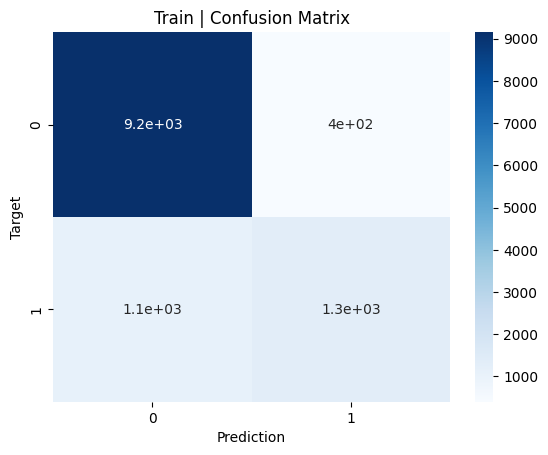

ROC-AUC on Validation: 0.7570


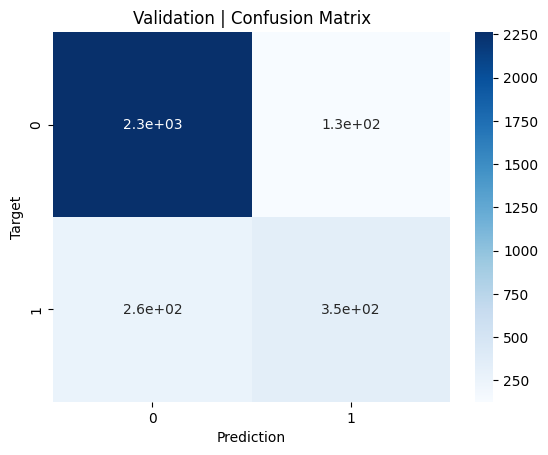

['logreg_pipeline.joblib']

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# 1. Читання даних
raw_df = pd.read_csv('/content/sample_data/train.csv', index_col=0)

# 2. Розбиття на train/val
train_df, val_df = train_test_split(
    raw_df,
    test_size=0.2,
    random_state=42,
    stratify=raw_df["Exited"]
)

# 3. Вхідні та цільові колонки
input_cols = [
    'CreditScore', 'Age', 'Tenure', 'Balance',
    'NumOfProducts', 'HasCrCard', 'IsActiveMember',
    'EstimatedSalary', 'Gender', 'Geography'
]
target_col = 'Exited'

train_inputs = train_df[input_cols]
train_targets = train_df[target_col]

val_inputs = val_df[input_cols]
val_targets = val_df[target_col]

# 4. Числові та категоріальні колонки
numeric_cols = [
    'CreditScore', 'Age', 'Tenure', 'Balance',
    'NumOfProducts', 'HasCrCard', 'IsActiveMember',
    'EstimatedSalary'
]

categorical_cols = ['Gender', 'Geography']

# 5. Трансформери
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 6. Препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# 7. Пайплайн моделі
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

# 8. Навчання
model_pipeline.fit(train_inputs, train_targets)

# Функція оцінки
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    roc_auc = roc_auc_score(targets, preds)
    print(f"ROC-AUC on {name}: {roc_auc:.4f}")
    cm = confusion_matrix(targets, preds)
    sns.heatmap(cm, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title(f'{name} | Confusion Matrix')
    plt.show()

# Оцінка на train і val
predict_and_plot(model_pipeline, train_inputs, train_targets, name='Train')
predict_and_plot(model_pipeline, val_inputs, val_targets, name='Validation')

# 9. Збереження моделі
joblib.dump(model_pipeline, 'logreg_pipeline.joblib')


**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

ROC-AUC on Train: 0.7726


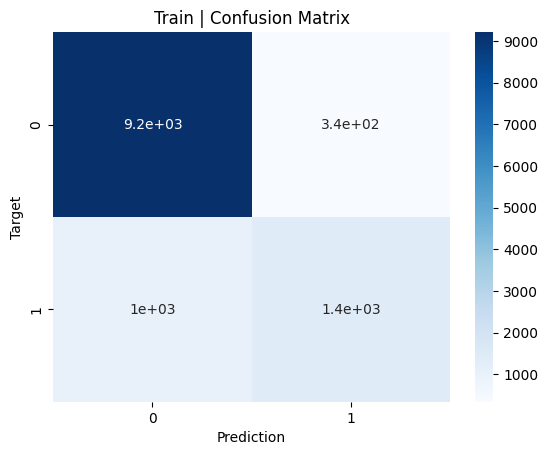

ROC-AUC on Validation: 0.7778


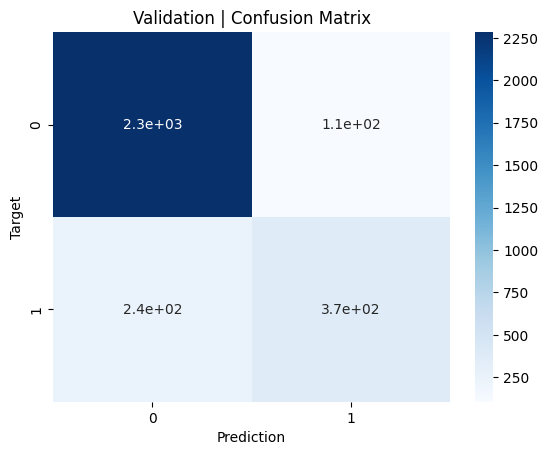

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Читання даних
raw_df = pd.read_csv('/content/sample_data/train.csv', index_col=0)

# 2. Розбиття на train/val
train_df, val_df = train_test_split(
    raw_df,
    test_size=0.2,
    random_state=42,
    stratify=raw_df["Exited"]
)

# 3. Вхідні та цільові колонки
input_cols = [
    'CreditScore', 'Age', 'Tenure', 'Balance',
    'NumOfProducts', 'HasCrCard', 'IsActiveMember',
    'EstimatedSalary', 'Gender', 'Geography'
]
target_col = 'Exited'

train_inputs = train_df[input_cols]
train_targets = train_df[target_col]

val_inputs = val_df[input_cols]
val_targets = val_df[target_col]

# 4. Числові та категоріальні колонки
numeric_cols = [
    'CreditScore', 'Age', 'Tenure', 'Balance',
    'NumOfProducts', 'HasCrCard', 'IsActiveMember',
    'EstimatedSalary'
]

categorical_cols = ['Gender', 'Geography']

# 5. Трансформери з PolynomialFeatures
numeric_transformer_poly = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 6. Новий препроцесор
preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# 7. Новий пайплайн
model_pipeline_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('classifier', LogisticRegression(max_iter=500))
])

# 8. Навчання
model_pipeline_poly.fit(train_inputs, train_targets)

# Функція оцінки
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    roc_auc = roc_auc_score(targets, preds)
    print(f"ROC-AUC on {name}: {roc_auc:.4f}")
    cm = confusion_matrix(targets, preds)
    sns.heatmap(cm, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title(f'{name} | Confusion Matrix')
    plt.show()

# 9. Оцінка на train і val
predict_and_plot(model_pipeline_poly, train_inputs, train_targets, name='Train')
predict_and_plot(model_pipeline_poly, val_inputs, val_targets, name='Validation')


Train ROC‑AUC: 0.7726
Validation ROC‑AUC: 0.7778 - валідаційний AUC навіть трохи вищий за тренувальний.

Висновок:



*   Модель не переобучена

*   Модель не недообучена
AUC > 0.77 — це нормальний рівень для логістичної регресії
*   немає великого розриву між train і val


*   Модель добре генералізує -
поведінка на train дуже близька поведінці на validation


**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

ROC-AUC on Train: 0.8101


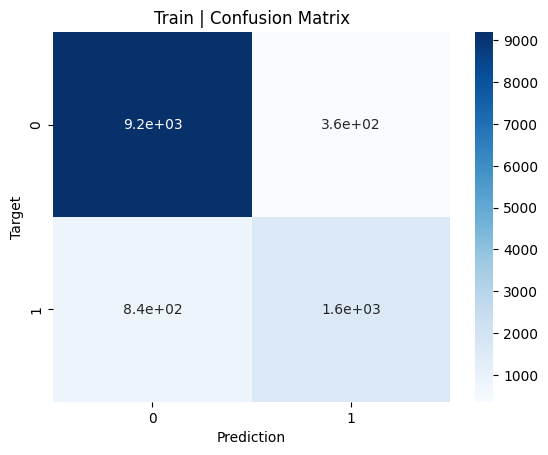

ROC-AUC on Validation: 0.8086


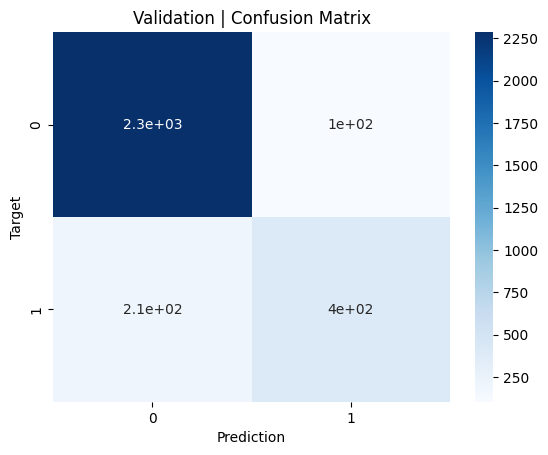

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Читання даних
raw_df = pd.read_csv('/content/sample_data/train.csv', index_col=0)

# 2. Розбиття на train/val
train_df, val_df = train_test_split(
    raw_df,
    test_size=0.2,
    random_state=42,
    stratify=raw_df["Exited"]
)

# 3. Вхідні та цільові колонки
input_cols = [
    'CreditScore', 'Age', 'Tenure', 'Balance',
    'NumOfProducts', 'HasCrCard', 'IsActiveMember',
    'EstimatedSalary', 'Gender', 'Geography'
]
target_col = 'Exited'

train_inputs = train_df[input_cols]
train_targets = train_df[target_col]

val_inputs = val_df[input_cols]
val_targets = val_df[target_col]

# 4. Числові та категоріальні колонки
numeric_cols = [
    'CreditScore', 'Age', 'Tenure', 'Balance',
    'NumOfProducts', 'HasCrCard', 'IsActiveMember',
    'EstimatedSalary'
]

categorical_cols = ['Gender', 'Geography']

# 5. PolynomialFeatures degree=4 + MinMaxScaler
numeric_transformer_poly4 = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=4, include_bias=False)),
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 6. Препроцесор
preprocessor_poly4 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly4, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# 7. Пайплайн моделі
model_pipeline_poly4 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly4),
    ('classifier', LogisticRegression(max_iter=1000))
])

# 8. Навчання
model_pipeline_poly4.fit(train_inputs, train_targets)

# Функція оцінки
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    roc_auc = roc_auc_score(targets, preds)
    print(f"ROC-AUC on {name}: {roc_auc:.4f}")
    cm = confusion_matrix(targets, preds)
    sns.heatmap(cm, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title(f'{name} | Confusion Matrix')
    plt.show()

# 9. Оцінка на train і val
predict_and_plot(model_pipeline_poly4, train_inputs, train_targets, name='Train')
predict_and_plot(model_pipeline_poly4, val_inputs, val_targets, name='Validation')


Train ROC‑AUC: 0.8101
Validation ROC‑AUC: 0.8086

Висновок:


*   різниця між train і val мінімальна

*   модель не завчила тренувальні дані, тобто не overfit
*   модель не провалилася на валідації? nj,nj yt overfit


*   якість degree=4 вища, ніж у degree=2 (0.81 проти 0.77)

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [7]:
df = pd.read_csv('/content/sample_data/regression_data.csv')

In [8]:
df.head()


,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,-0.190339,-1.382800,-0.875618,0.538910,-1.037246,28.938854
1,-0.321386,-0.563725,0.412931,-0.147057,-0.825497,-7.664581
2,2.122156,-1.519370,1.032465,-1.260884,0.917862,-63.845482
3,-1.380101,-0.055548,-1.703382,0.074095,1.628616,4.076259
4,-0.072829,-1.514847,-0.846794,0.714000,0.473238,34.879013


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   feature_1  129 non-null    float64
 1   feature_2  129 non-null    float64
 2   feature_3  129 non-null    float64
 3   feature_4  129 non-null    float64
 4   feature_5  129 non-null    float64
 5   target     129 non-null    float64
dtypes: float64(6)
memory usage: 6.2 KB


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Читання даних
df = pd.read_csv('/content/sample_data/regression_data.csv')

# 2. Розбиття на train/test
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

# 3. Вхідні та цільові колонки
input_cols = ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']
target_col = 'target'

train_inputs = train_df[input_cols]
train_targets = train_df[target_col]

test_inputs = test_df[input_cols]
test_targets = test_df[target_col]

# 4. PolynomialFeatures degree=5 + MinMaxScaler
numeric_transformer_poly5 = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('scaler', MinMaxScaler())
])

# 5. Препроцесор
preprocessor_poly5 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly5, input_cols)
    ]
)

# 6. Пайплайн моделі
model_pipeline_poly5 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly5),
    ('regressor', LinearRegression())
])

# 7. Навчання
model_pipeline_poly5.fit(train_inputs, train_targets)

# 8. Оцінка на train
train_preds = model_pipeline_poly5.predict(train_inputs)
train_mse = mean_squared_error(train_targets, train_preds)
train_r2 = r2_score(train_targets, train_preds)

print(f"Train MSE: {train_mse:.4f}")
print(f"Train R2: {train_r2:.4f}")

# 9. Оцінка на test
test_preds = model_pipeline_poly5.predict(test_inputs)
test_mse = mean_squared_error(test_targets, test_preds)
test_r2 = r2_score(test_targets, test_preds)

print(f"Test MSE: {test_mse:.4f}")
print(f"Test R2: {test_r2:.4f}")


Train MSE: 0.0000
Train R2: 1.0000
Test MSE: 152.8509
Test R2: 0.9345


In [11]:
# Оцінка пропорції кількості даних і нових фічей
pre = model_pipeline_poly5.named_steps['preprocessor']
X_poly = pre.transform(train_inputs)
X_poly.shape


(103, 251)

Модель лінійної регресії з поліноміальними ознаками до 5-го степеня показала гарні показники для тренувальних  даних Train MSE: 0.0000 та
Train R2: 1.0000,але погані на тестових. Особливо MSE на тестових - 152,8509. Висока точність на тренувальних даних і значне падіння на тестових свідчать про переобучення — модель запам’ятала тренувальні приклади, але не здатна добре узагальнювати нові. Тоюто модель погано генералізує.

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# 1. Завантаження даних
data = pd.read_csv("/content/sample_data/regression_data.csv")
X = data.drop("target", axis=1)
y = data["target"]

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Поліноміальні ознаки до степеня 20
poly = PolynomialFeatures(degree=20, include_bias=False)

# 4. Масштабування MinMax
scaler = MinMaxScaler()

# 5. Моделі
models = {
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(alpha=0.001, max_iter=10000),
    "Ridge": Ridge(alpha=1.0),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000)
}

results = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("poly", poly),
        ("scaler", scaler),
        ("model", model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)
    results[name] = {
        "R2_train": r2_score(y_train, y_pred_train),
        "R2_test": r2_score(y_test, y_pred_test),
        "MSE_train": mean_squared_error(y_train, y_pred_train),
        "MSE_test": mean_squared_error(y_test, y_pred_test)
    }

# 6. Вивід результатів
for name, metrics in results.items():
    print(name, metrics)


LinearRegression {'R2_train': 1.0, 'R2_test': 0.8946947567912537, 'MSE_train': 4.1458957341890445e-23, 'MSE_test': 245.6840300048198}
Lasso {'R2_train': 0.9998498816493645, 'R2_test': 0.9839765954989808, 'MSE_train': 0.29240493372708126, 'MSE_test': 37.38365224990805}
Ridge {'R2_train': 0.9620493928389854, 'R2_test': -1.5125090868419062, 'MSE_train': 73.9213075872493, 'MSE_test': 5861.84827146175}
ElasticNet {'R2_train': 0.9992696213594178, 'R2_test': 0.8858729961280339, 'MSE_train': 1.4226529740768061, 'MSE_test': 266.2657754662631}


Лінійна регресія демонструє ідеальне навчання (R²_train = 1.0), але помітно гіршу узагальнювальну здатність на тесті. Найкращий баланс між тренувальними й тестовими результатами показує Lasso - високе R²_test майже 0.98 та значно нижча MSE порівняно з іншими моделями. Ridge та ElasticNet у цьому випадку працюють нестабільно: Ridge сильно переобмежує модель (негативний R²_test), а ElasticNet має слабку якість на тесті. Загалом, Lasso є оптимальним вибором для цього набору даних.